# 13. Real Data: Joint Optimization: FWHM + Sigma Matching

**Goal:** jointly optimize mu and gamma by matching **both** the FWHM distribution and the fit-uncertainty distribution.

| Gradient | Source | Why |
|---|---|---|
| **mu** (REINFORCE) | Per-quantile reward: -W1(FWHM) - l*W1(sigma) | sigma encodes photon count statistics directly |
| **gamma** (implicit diff) | dLoss/dgamma = W1'(FWHM)*dFWHM/dgamma + l*W1'(sigma)*dsigma/dgamma | Matching both tightens gamma constraints |

**dsigma/dgamma** is approximated via CRLB: sigma ~ 2*gamma/sqrt(n) -> dsigma/dgamma ~ 2/sqrt(n).

All model code from `src/`.

In [1]:
import sys
import sys; sys.path.insert(0, "..")
import math, time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

from src.fitting import (
    _raw_from_width as _rw,
    log_pdf, nll, fwhm_from_theta, fit_profile
)
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
LAMBDA_ = 2.0

N_RUNS = 200
N_ITER = 80

SIGMA_PROP = 6.0          # physical noise std
LR_MU = 15.0              # learning rate for mu
LR_GAMMA = 1.5             # 3x original
BASELINE_ALPHA = 0.05     # EMA smoothing
CLIP = 10.0               # gradient clipping

LAMBDA_SIGMA = 0.1        # reduced from 0.3 (was constraining gamma)
LAMBDA_GAMMA_SIGMA = 0.1  # reduced sigma contribution in gamma gradient
LAMBDA_MEAN = 5.0         # weight for mean FWHM matching

MU_INIT = 30.0
GAMMA_INIT = 15.0
SEED = 42

print('Parameters set')


Parameters set


## Generate Target Data

Collect both FWHM and sigma_FWHM from real data (3nW, 40% transmission).

In [3]:
t_total = time.time()

# Build fit/nll/fwhm wrappers (Lorentzian, no background)
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

df = pd.read_csv('../data/processed/fwhm_linewidths.csv')
SCALE = 1000.0
cond = (df['power_nW'] == 3) & (df['transmission'] == 40)
sub = df[cond].dropna(subset=['fwhm', 'fit_error'])
err_max = np.percentile(sub['fit_error'].values, 99)
sub = sub[sub['fit_error'] <= err_max]
target_raw = sub['fwhm'].values * SCALE
target_fit_err = sub['fit_error'].values * SCALE
target_data = torch.tensor(target_raw, dtype=torch.float32)
N_DATAPOINTS = len(target_data)

target_fwhms = target_data.tolist()
target_sigmas = target_fit_err.tolist()

print(f'Target: {len(target_data)} FWHM values from real data (3nW, 40% transmission)')
print(f'  FWHM mean: {target_data.mean():.2f}, std: {target_data.std():.2f}')
print(f'  Sigma mean: {np.mean(target_fit_err):.4f}, std: {np.std(target_fit_err):.4f}')
print(f'  Range FWHM: [{target_data.min():.2f}, {target_data.max():.2f}]')
print(f'  Range sigma: [{np.min(target_fit_err):.4f}, {np.max(target_fit_err):.4f}]')

target_t = torch.tensor(target_fwhms, dtype=torch.float32)
target_s_t = torch.tensor(target_sigmas, dtype=torch.float32)
st = torch.sort(target_t)[0]
st_sig = torch.sort(target_s_t)[0]




# Precompute random quantile indices for each step (cover full distribution)
from numpy.random import default_rng
n_total = len(st)
quantile_rng = default_rng(SEED + 999)
quantile_idx = []
for step in range(N_ITER):
    idx = np.sort(quantile_rng.choice(n_total, N_RUNS, replace=False))
    quantile_idx.append(idx)

print(f'Precomputed {N_ITER} sets of {N_RUNS} random quantile indices each')
print(f'Full data has {n_total} sorted FWHM values')


Target: 3725 FWHM values from real data (3nW, 40% transmission)
  FWHM mean: 26.89, std: 10.18
  Sigma mean: 2.2118, std: 3.3675
  Range FWHM: [0.88, 89.94]
  Range sigma: [0.1866, 42.4740]
Precomputed 80 sets of 200 random quantile indices each
Full data has 3725 sorted FWHM values


## Joint Optimization: FWHM + Sigma

### mu update (REINFORCE)
Per-quantile reward combines FWHM and sigma matches, using `adv = loss - baseline` for consistent signs:
```
cl_i = |FWHM_(i) - target_(i)| + l_sig * |sigma_(i) - sigma_target_(i)| + l_mean * |FWHM_mean - target_mean|
adv_i = cl_i - baseline
grad_mu = mean(adv_i * (n_i - mu) / sigma^2)
```

### gamma update (implicit diff + CRLB)
```
grad_gamma_FWHM  = mean(sign(FWHM_i - target_i) * dFWHM_i/dgamma)
grad_gamma_sigma = mean(sign(sigma_i - sigma_target_i) * dsigma_i/dgamma)    # dsigma/dgamma ~ 2/sqrt(n)
grad_gamma = grad_gamma_FWHM + l * grad_gamma_sigma
```

In [4]:
mu_val = float(MU_INIT)
gamma_val = float(GAMMA_INIT)
bl = 0.0
history = []

print(f"mu_init={MU_INIT}, gamma_init={GAMMA_INIT}")
print(f"N_ITER={N_ITER}, N_RUNS={N_RUNS}, lambda_sig={LAMBDA_SIGMA}, lambda_gamma_sig={LAMBDA_GAMMA_SIGMA}\n")

for step in range(N_ITER):
    # Select random quantiles covering the full distribution
    idx = quantile_idx[step]
    st_step = st[idx]
    st_sig_step = st_sig[idx]
    rng2 = np.random.default_rng(SEED + step)
    fwhms, sigmas, dfs, ns = [], [], [], []
    
    for _ in range(N_RUNS):
        u, b, n = draw_fixed_noise(mu_val, SIGMA_PROP, LAMBDA_, rng2)
        ns.append(n)
        fw, sig, dg = compute_fwhm_and_dgamma(
            gamma_val, u.numpy(), b.numpy(),
            _fit_fn, _fwhm_fn, _nll_fn, n_params=2
        )
        fwhms.append(fw)
        sigmas.append(sig)
        dfs.append(dg)
    
    ft = torch.tensor(fwhms, dtype=torch.float32)
    si_t = torch.tensor(sigmas, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor(dfs, dtype=torch.float32)
    
    # Sorted quantile matching
    sf, sidx = torch.sort(ft)
    pl = torch.abs(sf - st_step)                   # FWHM loss per quantile
    nss = nt[sidx]                               # n sorted by FWHM rank
    dgs = dg_t[sidx]                             # dFWHM/dgamma sorted by FWHM rank
    ss = si_t[sidx]                              # sigma sorted by FWHM rank
    
    # Sigma loss per quantile (same sort order)
    pl_sig = torch.abs(ss - st_sig_step)
    # Mean-matching loss
    mean_fwhm_loss = torch.abs(ft.mean() - target_t.mean())
    
    # Combined per-quantile loss with mean matching
    cl = pl + LAMBDA_SIGMA * pl_sig + LAMBDA_MEAN * mean_fwhm_loss
    
    loss_fwhm = pl.mean()
    loss_sigma = pl_sig.mean()
    mean_loss = (loss_fwhm + LAMBDA_SIGMA * loss_sigma + LAMBDA_MEAN * mean_fwhm_loss).item()
    mean_fwhm_loss_val = mean_fwhm_loss.item()
    loss_fwhm_val = loss_fwhm.item()
    loss_sigma_val = loss_sigma.item()
    
    # Baseline
    if step == 0:
        bl = mean_loss
    else:
        bl = (1 - BASELINE_ALPHA) * bl + BASELINE_ALPHA * mean_loss
    
    # ---- MU gradient: REINFORCE ----
    adv = (cl.detach() - bl).numpy()
    scores = (nss.numpy() - mu_val) / SIGMA_PROP**2
    raw_grad_mu = float(np.mean(adv * scores))
    grad_mu = max(min(raw_grad_mu, CLIP), -CLIP)
    mu_val += LR_MU * (-grad_mu)
    mu_val = max(1.0, min(200.0, mu_val))
    
    # ---- GAMMA gradient: implicit diff (FWHM) + CRLB (sigma) ----
    # dsigma/dgamma per run: CRLB ~= 2/sqrt(n)
    dsigs = torch.tensor([min(2.0 / math.sqrt(max(int(n), 1)), 2.0) for n in ns], dtype=torch.float32)
    ds_s = dsigs[sidx]
    
    signs_fw = torch.sign(sf - st_step)
    signs_sg = torch.sign(ss - st_sig_step)
    raw_grad_fwhm = float((signs_fw * dgs).mean().item())
    raw_grad_sigma = float((signs_sg * ds_s).mean().item())
    raw_grad_gamma = raw_grad_fwhm + LAMBDA_GAMMA_SIGMA * raw_grad_sigma
    grad_gamma = max(min(raw_grad_gamma, CLIP), -CLIP)
    gamma_val += LR_GAMMA * (-grad_gamma)
    gamma_val = max(0.1, min(100.0, gamma_val))
    
    # Diagnostics
    rho = float(np.corrcoef(nss.numpy(), pl.numpy())[0, 1]) if pl.std() > 0.01 and nss.std() > 0.01 else 0.0
    
    info = {
        'step': step,
        'mu': mu_val, 'gamma': gamma_val,
        'loss': mean_loss, 'loss_fwhm': loss_fwhm_val, 'loss_sigma': loss_sigma_val,
        'baseline': bl,
        'grad_mu': grad_mu, 'grad_gamma': grad_gamma,
        'rho': rho, 'mean_n': float(np.mean(ns)),
        'mean_fwhm': float(ft.mean().item()),
        'mean_sigma': float(ss.mean().item()),
    }
    history.append(info)
    
    if step % 5 == 0 or step == N_ITER - 1:
        print(f"  S{step:2d}: mu={mu_val:6.2f} gamma={gamma_val:5.1f} | "
              f"L={mean_loss:.2f}(F={loss_fwhm_val:.2f}+S={loss_sigma_val:.2f}) | "
              f"grad_mu={grad_mu:+.4f} grad_gamma={grad_gamma:+.4f} | "
              f"nbar={info['mean_n']:4.1f} rho={rho:+.3f} "
              f"({time.time()-t_total:.0f}s)", flush=True)

print(f"\nDone. {time.time()-t_total:.0f}s")

mu_init=30.0, gamma_init=15.0
N_ITER=80, N_RUNS=200, lambda_sig=0.1, lambda_gamma_sig=0.1



  S 0: mu= 30.96 gamma= 11.7 | L=39.30(F=7.58+S=0.80) | grad_mu=-0.0643 grad_gamma=+2.1756 | nbar=29.8 rho=-0.119 (4s)


  S 5: mu= 20.50 gamma=  9.7 | L=14.74(F=2.68+S=0.74) | grad_mu=+0.2523 grad_gamma=+1.8222 | nbar=23.0 rho=-0.160 (19s)


  S10: mu= 24.57 gamma= 13.6 | L=17.18(F=2.89+S=0.85) | grad_mu=+0.0268 grad_gamma=-2.0733 | nbar=24.9 rho=-0.020 (34s)


  S15: mu= 33.60 gamma= 13.8 | L=12.18(F=2.35+S=1.12) | grad_mu=-0.1600 grad_gamma=-1.6142 | nbar=31.5 rho=-0.029 (49s)


...

  S65: mu= 52.19 gamma= 12.0 | L=8.39(F=3.25+S=1.07) | grad_mu=-0.0804 grad_gamma=+0.6246 | nbar=51.8 rho=-0.032 (202s)


  S70: mu= 55.75 gamma= 12.7 | L=11.91(F=3.46+S=1.51) | grad_mu=+0.0165 grad_gamma=+0.6416 | nbar=56.1 rho=+0.038 (217s)


  S75: mu= 60.52 gamma= 13.2 | L=10.01(F=3.15+S=1.63) | grad_mu=-0.1017 grad_gamma=-0.7437 | nbar=59.2 rho=-0.128 (232s)


  S79: mu= 62.85 gamma= 11.8 | L=4.55(F=3.94+S=1.68) | grad_mu=-0.0673 grad_gamma=+0.6688 | nbar=61.9 rho=-0.078 (245s)



Done. 245s


## Results

In [5]:
if len(history) > 0:
    fmu = history[-1]['mu']
    fga = history[-1]['gamma']
    print(f"{'='*65}")
    print(f"  JOINT OPTIMIZATION - FWHM + SIGMA MATCHING")
    print(f"{'='*65}")
    print(f"  mu:    {MU_INIT:.0f} -> {fmu:.2f}")
    print(f"  gamma: {GAMMA_INIT:.0f} -> {fga:.2f}")
    print(f"  Loss:  {history[0]['loss']:.2f} -> {history[-1]['loss']:.2f}")
    print(f"  FWHM:  {history[0]['loss_fwhm']:.2f} -> {history[-1]['loss_fwhm']:.2f}")
    print(f"  Sigma: {history[0]['loss_sigma']:.2f} -> {history[-1]['loss_sigma']:.2f}")
    print(f"  mu final grad: {history[-1]['grad_mu']:+.4f}")
    print(f"  Time:  {time.time()-t_total:.0f}s")
    print(f"{'='*65}")

  JOINT OPTIMIZATION - FWHM + SIGMA MATCHING
  mu:    30 -> 62.85
  gamma: 15 -> 11.83
  Loss:  39.30 -> 4.55
  FWHM:  7.58 -> 3.94
  Sigma: 0.80 -> 1.68
  mu final grad: -0.0673
  Time:  245s


## Visualization for Presentation

### mu and gamma convergence + trajectory + FWHM distribution comparison

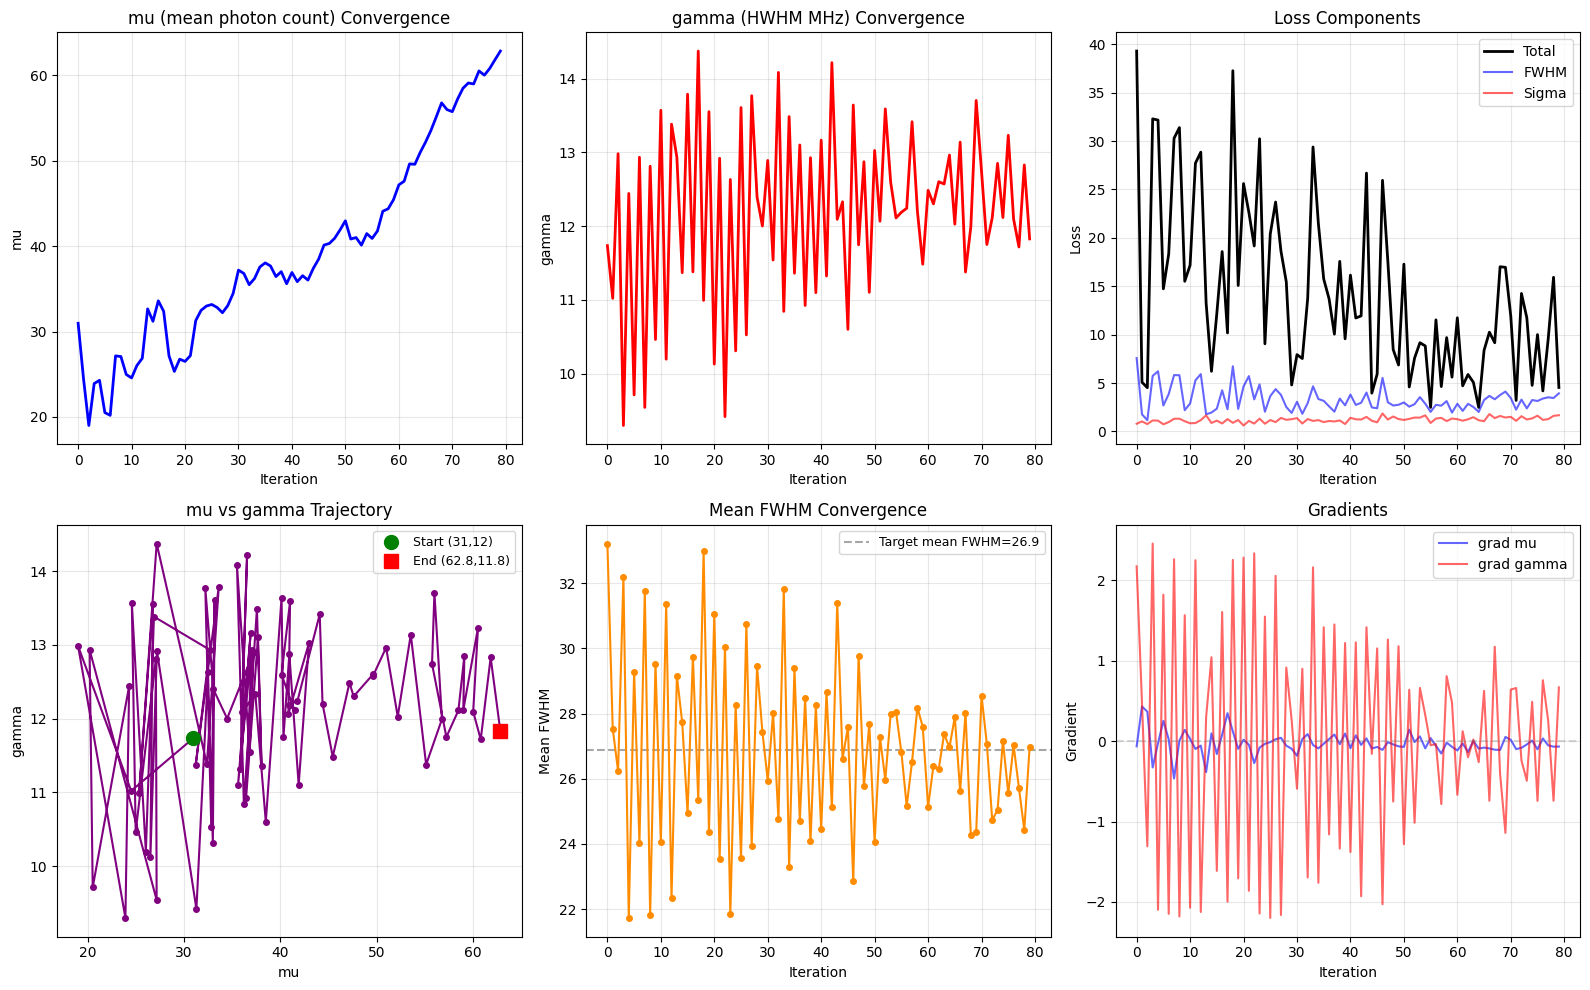

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from src.losses import wasserstein_loss

steps = [h['step'] for h in history]
mu_hist = [h['mu'] for h in history]
gamma_hist = [h['gamma'] for h in history]
loss_hist = [h['loss'] for h in history]
loss_f_hist = [h['loss_fwhm'] for h in history]
loss_s_hist = [h['loss_sigma'] for h in history]
mean_fwhm_hist = [h['mean_fwhm'] for h in history]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- mu convergence ---
ax = axes[0, 0]
ax.plot(steps, mu_hist, 'b-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('mu')
ax.set_title('mu (mean photon count) Convergence'); ax.grid(alpha=0.3)

# --- gamma convergence ---
ax = axes[0, 1]
ax.plot(steps, gamma_hist, 'r-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('gamma')
ax.set_title('gamma (HWHM MHz) Convergence'); ax.grid(alpha=0.3)

# --- Loss components ---
ax = axes[0, 2]
ax.plot(steps, loss_hist, 'k-', linewidth=2, label='Total')
ax.plot(steps, loss_f_hist, 'b-', alpha=0.6, label='FWHM')
ax.plot(steps, loss_s_hist, 'r-', alpha=0.6, label='Sigma')
ax.set_xlabel('Iteration'); ax.set_ylabel('Loss')
ax.set_title('Loss Components'); ax.legend(); ax.grid(alpha=0.3)

# --- mu vs gamma trajectory ---
ax = axes[1, 0]
ax.plot(mu_hist, gamma_hist, 'o-', color='purple', markersize=4, linewidth=1.5)
ax.plot(mu_hist[0], gamma_hist[0], 'go', markersize=10, label=f'Start ({mu_hist[0]:.0f},{gamma_hist[0]:.0f})')
ax.plot(mu_hist[-1], gamma_hist[-1], 'rs', markersize=10, label=f'End ({mu_hist[-1]:.1f},{gamma_hist[-1]:.1f})')
ax.set_xlabel('mu'); ax.set_ylabel('gamma')
ax.set_title('mu vs gamma Trajectory'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# --- Mean FWHM ---
ax = axes[1, 1]
target_mean = target_t.mean().item()
ax.axhline(target_mean, color='gray', ls='--', linewidth=1.5, alpha=0.7, label=f'Target mean FWHM={target_mean:.1f}')
ax.plot(steps, mean_fwhm_hist, 'o-', color='darkorange', markersize=4)
ax.set_xlabel('Iteration'); ax.set_ylabel('Mean FWHM')
ax.set_title('Mean FWHM Convergence'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# --- Gradient norms ---
ax = axes[1, 2]
grad_mu = [h['grad_mu'] for h in history]
grad_gamma = [h['grad_gamma'] for h in history]
ax.plot(steps, grad_mu, 'b-', alpha=0.6, label='grad mu')
ax.plot(steps, grad_gamma, 'r-', alpha=0.6, label='grad gamma')
ax.axhline(0, color='gray', ls='--', alpha=0.3)
ax.set_xlabel('Iteration'); ax.set_ylabel('Gradient')
ax.set_title('Gradients'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Generating final forward pass for distribution comparison...


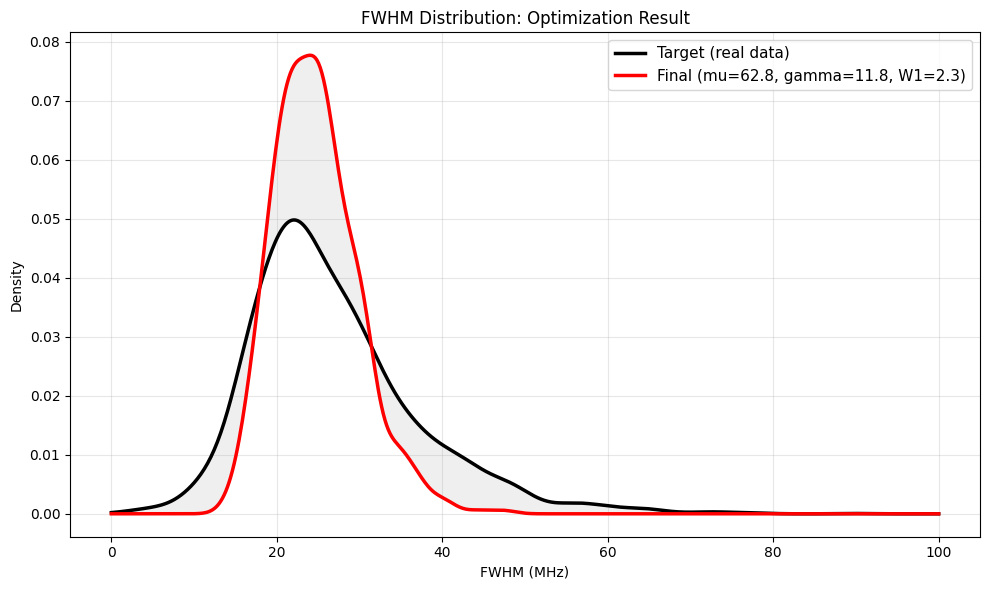

Target FWHM: 26.9 +/- 10.2
Final  FWHM: 24.8 +/- 5.1


In [7]:
# Final forward pass for FWHM distribution comparison
print('Generating final forward pass for distribution comparison...')
rng_f = np.random.default_rng(999)
final_fwhms = []
for _ in range(500):
    u, b, n = draw_fixed_noise(mu_hist[-1], SIGMA_PROP, LAMBDA_, rng_f)
    photons = build_photons(torch.tensor(gamma_hist[-1], dtype=torch.float32), u, b)
    theta = fit_profile(photons, n_iters=80, model='lorentzian', uniform_bg=False)
    if theta is not None:
        final_fwhms.append(fwhm_from_theta(theta, model='lorentzian').item())
    else:
        final_fwhms.append(2.0 * gamma_hist[-1])
final_t = torch.tensor(final_fwhms, dtype=torch.float32)

# Target vs Final KDE (initial pass skipped for real data)
x_grid = np.linspace(0, 100, 500)
kde_target = gaussian_kde(target_t.numpy())
kde_final = gaussian_kde(final_t.numpy())
w1_final = wasserstein_loss(final_t, target_t).item()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label='Target (real data)')
ax.plot(x_grid, kde_final(x_grid), 'r-', linewidth=2.5, label=f'Final (mu={mu_hist[-1]:.1f}, gamma={gamma_hist[-1]:.1f}, W1={w1_final:.1f})')
ax.fill_between(x_grid, kde_final(x_grid), kde_target(x_grid), alpha=0.12, color='gray')
ax.set_xlabel('FWHM (MHz)'); ax.set_ylabel('Density')
ax.set_title('FWHM Distribution: Optimization Result')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Target FWHM: {target_t.mean():.1f} +/- {target_t.std():.1f}')
print(f'Final  FWHM: {final_t.mean():.1f} +/- {final_t.std():.1f}')


## Distribution Diagnostics

Comparison of target vs optimized distributions.


In [8]:
# Distribution diagnostics
from scipy.stats import wasserstein_distance

target_np = target_t.numpy()
final_np = final_t.numpy()

print('='*65)
print('DISTRIBUTION DIAGNOSTICS')
print('='*65)

print(f'{"Metric":<25} {"Target":>12} {"Final":>12} {"Ratio":>10}')
print('-'*60)
print(f'{"Mean FWHM":<25} {target_np.mean():>12.2f} {final_np.mean():>12.2f} {final_np.mean()/target_np.mean():>10.3f}')
print(f'{"Std FWHM":<25} {target_np.std():>12.2f} {final_np.std():>12.2f} {final_np.std()/target_np.std():>10.3f}')
print(f'{"P5 FWHM":<25} {np.percentile(target_np,5):>12.2f} {np.percentile(final_np,5):>12.2f}')
print(f'{"P95 FWHM":<25} {np.percentile(target_np,95):>12.2f} {np.percentile(final_np,95):>12.2f}')
print(f'{"W1 distance":<25} {w1_final:>12.3f}')
print()
print(f'Optimized mu: {mu_hist[-1]:.2f}')
print(f'Optimized gamma: {gamma_hist[-1]:.2f}')
print(f'Gamma trajectory (last 10): {[round(h["gamma"],2) for h in history[-10:]]}')
print(f'Mu trajectory (last 10): {[round(h["mu"],2) for h in history[-10:]]}')


DISTRIBUTION DIAGNOSTICS
Metric                          Target        Final      Ratio
------------------------------------------------------------
Mean FWHM                        26.89        24.76      0.921
Std FWHM                         10.18         5.05      0.496
P5 FWHM                          14.23        17.63
P95 FWHM                         46.46        34.26
W1 distance                      2.281

Optimized mu: 62.85
Optimized gamma: 11.83
Gamma trajectory (last 10): [12.74, 11.75, 12.11, 12.85, 12.12, 13.23, 12.1, 11.72, 12.83, 11.83]
Mu trajectory (last 10): [55.75, 57.24, 58.49, 59.11, 59.0, 60.52, 60.02, 60.81, 61.84, 62.85]


# 13e: Moderate Gamma LR — Conclusions

## 13d Results

- gamma: 15→18.5, mean FWHM: 38.6 (too high), std: 8.13 (79%)
- LR_GAMMA=5 too high — oscillations between 8-19
- Confirms higher gamma increases std, but need right balance

## Fix in 13e

- LR_GAMMA: 0.5 → 1.5 (3x, not 10x — to avoid oscillation)
